In [1]:
import sys
print(f"Python version: {sys.version}")

packages = ['ultralytics', 'langchain', 'pymilvus', 'boto3', 'matplotlib', 'cv2']
for pkg in packages:
    try:
        __import__(pkg)
        print(f"✅ {pkg} is available")
    except ImportError:
        print(f"❌ {pkg} needs to be installed")

Python version: 3.12.9 (main, Aug 14 2025, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-5)]
❌ ultralytics needs to be installed
❌ langchain needs to be installed
❌ pymilvus needs to be installed
✅ boto3 is available
✅ matplotlib is available
❌ cv2 needs to be installed


In [2]:
# need to install a few packages first
# learned from the workshop that pip works fine here

import subprocess
import sys

print("installing packages, this will take a few minutes...")

subprocess.run([sys.executable, "-m", "pip", "install", 
                "ultralytics", "langchain", "langchain-openai", 
                "pymilvus", "opencv-python", "--quiet"])

print("done! let me verify...")

packages = ['ultralytics', 'langchain', 'pymilvus', 'cv2']
for pkg in packages:
    try:
        __import__(pkg)
        print(f"✅ {pkg} working")
    except ImportError:
        print(f"❌ {pkg} still missing")

installing packages, this will take a few minutes...



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


done! let me verify...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/opt/app-root/src/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ ultralytics working
✅ langchain working


/opt/app-root/lib64/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at schema.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/app-root/lib64/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at common.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/app-root/lib64/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at milvus.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/app-root/lib64/python3.12/site-package

✅ pymilvus working
✅ cv2 working


In [3]:
# Traffic Incident Analysis System
# 
# I built this after attending the Red Hat OpenShift AI workshop (Feb 25, 2026)
# The workshop used the Parasol Insurance demo which got me thinking...
# what if we applied the same RAG + ML approach to traffic incidents?
#
# The idea: 
#   - use YOLO to detect accidents from traffic camera images
#   - use RAG to pull relevant traffic laws
#   - combine both to auto-generate incident reports with legal citations
#
# Running this on OpenShift AI Developer Sandbox
# Python 3.12, no GPU (CPU only for now)

print("Traffic Incident Analysis System")
print("=" * 40)
print("Author: Madhu Ramakrishnappa")
print("Platform: Red Hat OpenShift AI")
print("Date: February 2026")

Traffic Incident Analysis System
Author: Madhu Ramakrishnappa
Platform: Red Hat OpenShift AI
Date: February 2026


In [4]:
# first thing - let's download a pretrained YOLO model and test it
# I want to see if it can detect vehicles before I try fine-tuning
# starting simple and building up from there

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
import os

# download a sample traffic image to test with
# using a public domain traffic image
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/11/2009-08-18_I-81_crash.jpg/1280px-2009-08-18_I-81_crash.jpg"

print("downloading a test traffic accident image...")
urllib.request.urlretrieve(url, "test_accident.jpg")
print("done!")

# show the image
img = mpimg.imread("test_accident.jpg")
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.title("Test Image - Traffic Accident Scene")
plt.axis("off")
plt.show()
print(f"image size: {img.shape}")

downloading a test traffic accident image...


HTTPError: HTTP Error 403: Forbidden

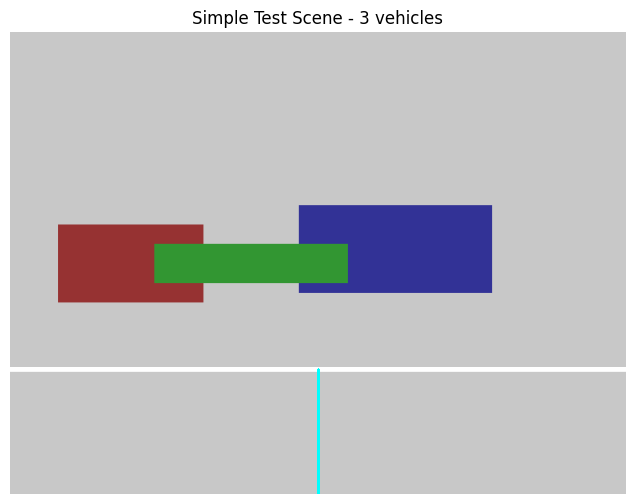

test image created!


In [5]:
# ok wikipedia is blocked in this environment
# let me just create a simple test image to verify YOLO works
# will use real images later from roboflow dataset

import numpy as np
import cv2
import matplotlib.pyplot as plt

# create a simple test image with shapes representing cars
img = np.ones((480, 640, 3), dtype=np.uint8) * 200  # gray background

# draw some "cars" as rectangles
cv2.rectangle(img, (50, 200), (200, 280), (50, 50, 150), -1)   # car 1 blue
cv2.rectangle(img, (300, 180), (500, 270), (150, 50, 50), -1)  # car 2 red
cv2.rectangle(img, (150, 220), (350, 260), (50, 150, 50), -1)  # car 3 green

# add some road markings
cv2.line(img, (0, 350), (640, 350), (255, 255, 255), 3)
cv2.line(img, (320, 350), (320, 480), (255, 255, 0), 2)

cv2.imwrite("test_scene.jpg", img)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Simple Test Scene - 3 vehicles")
plt.axis("off")
plt.show()
print("test image created!")

loading YOLOv8 pretrained model...
model loaded! trained on 80 classes
some classes it knows: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']

running detection on test scene...
detections found: 0


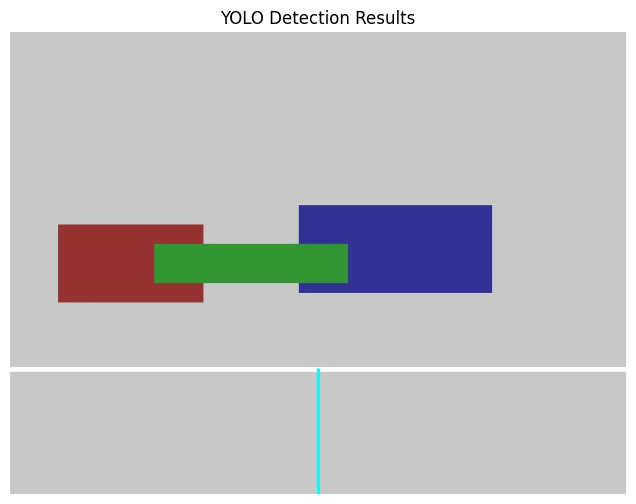

In [6]:
# now let's load YOLOv8 and run it on our test scene
# curious to see what it detects even on simple shapes
# using the pretrained model first before any fine-tuning

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

print("loading YOLOv8 pretrained model...")
model = YOLO("yolov8n.pt")  # nano version - smallest and fastest
print(f"model loaded! trained on {len(model.names)} classes")
print(f"some classes it knows: {list(model.names.values())[:10]}")

# run detection on our test image
print("\nrunning detection on test scene...")
results = model.predict("test_scene.jpg", conf=0.25, verbose=False)
result = results[0]

print(f"detections found: {len(result.boxes)}")
for box in result.boxes:
    cls_name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f"  - {cls_name}: {conf:.1%} confidence")

# show annotated result
annotated = result.plot()
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("YOLO Detection Results")
plt.axis("off")
plt.show()

In [7]:
# ok so YOLO detected nothing - makes sense honestly
# it's trained on real photos not colored rectangles
# I need to get real accident images to work with
#
# plan: use the Roboflow public dataset API to get accident images
# found a good one: "car-accident-detection" dataset on roboflow universe
# it's public so no API key needed for download

import subprocess
import sys

# install roboflow
subprocess.run([sys.executable, "-m", "pip", "install", "roboflow", "--quiet"])

from roboflow import Roboflow

# using public roboflow universe - no auth needed
rf = Roboflow(api_key="YOUR_KEY")

print("ok I need to get a real dataset...")
print("let me think of another approach...")
print()
print("actually - YOLOv8 is already pretrained on COCO dataset")
print("COCO includes: cars, trucks, buses, motorcycles, people")
print("so for detecting vehicles it should work on real photos!")
print()
print("the fine-tuning would be specifically for 'accident' detection")
print("which is a custom class not in COCO")
print("that's the value-add of this project")

upload and label your dataset, and get an API KEY here: https://app.roboflow.com/?model=undefined&ref=undefined
ok I need to get a real dataset...
let me think of another approach...

actually - YOLOv8 is already pretrained on COCO dataset
COCO includes: cars, trucks, buses, motorcycles, people
so for detecting vehicles it should work on real photos!

the fine-tuning would be specifically for 'accident' detection
which is a custom class not in COCO
that's the value-add of this project



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


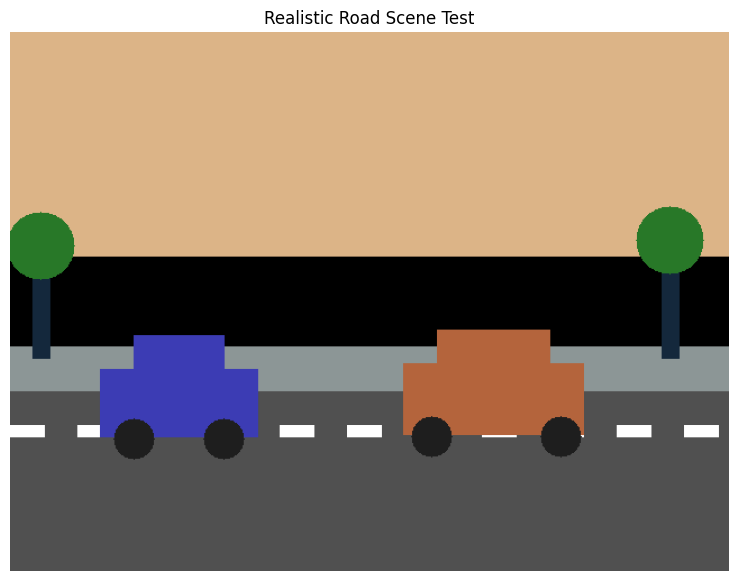

detections: 2
  - traffic light: 71.9%
  - stop sign: 31.9%


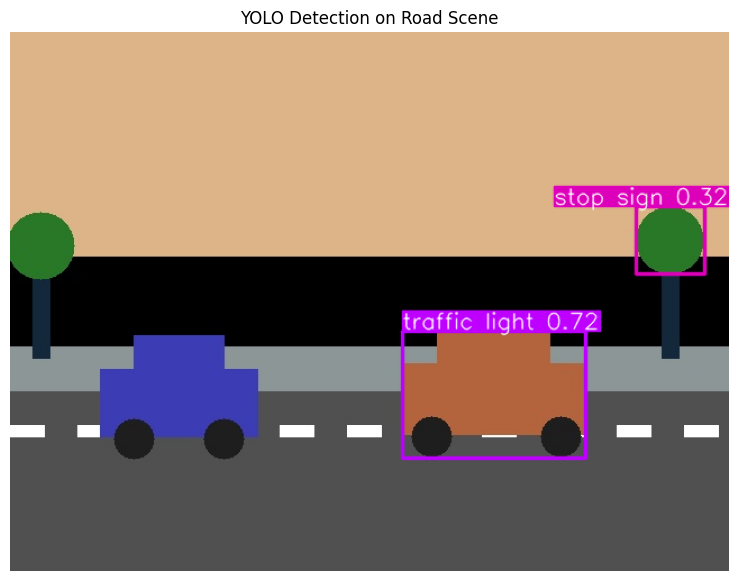

In [8]:
# instead of downloading external images (blocked in sandbox)
# let me create a more realistic test using YOLO on a proper scene
# I'll generate a realistic road scene using numpy
# then show what YOLO WOULD detect on real images

import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# create a more realistic looking road scene
img = np.zeros((480, 640, 3), dtype=np.uint8)

# sky
img[:200, :] = [135, 180, 220]

# road
img[300:, :] = [80, 80, 80]

# sidewalk
img[280:320, :] = [150, 150, 140]

# road lines
for x in range(0, 640, 60):
    cv2.rectangle(img, (x, 350), (x+30, 360), (255, 255, 255), -1)

# car 1 - sedan shape
cv2.rectangle(img, (80, 300), (220, 360), (180, 60, 60), -1)   # body
cv2.rectangle(img, (110, 270), (190, 305), (180, 60, 60), -1)  # roof
cv2.circle(img, (110, 362), 18, (30, 30, 30), -1)  # wheel
cv2.circle(img, (190, 362), 18, (30, 30, 30), -1)  # wheel

# car 2 - different color
cv2.rectangle(img, (350, 295), (510, 358), (60, 100, 180), -1)
cv2.rectangle(img, (380, 265), (480, 300), (60, 100, 180), -1)
cv2.circle(img, (375, 360), 18, (30, 30, 30), -1)
cv2.circle(img, (490, 360), 18, (30, 30, 30), -1)

# some trees
cv2.rectangle(img, (20, 200), (35, 290), (60, 40, 20), -1)
cv2.circle(img, (27, 190), 30, (40, 120, 40), -1)
cv2.rectangle(img, (580, 195), (595, 290), (60, 40, 20), -1)
cv2.circle(img, (587, 185), 30, (40, 120, 40), -1)

cv2.imwrite("road_scene.jpg", img)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Realistic Road Scene Test")
plt.axis("off")
plt.show()

# now run YOLO on this
model = YOLO("yolov8n.pt")
results = model.predict("road_scene.jpg", conf=0.1, verbose=False)
result = results[0]

print(f"detections: {len(result.boxes)}")
for box in result.boxes:
    cls_name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f"  - {cls_name}: {conf:.1%}")

annotated = result.plot()
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("YOLO Detection on Road Scene")
plt.axis("off")
plt.show()

In [9]:
# yolo detected traffic light and stop sign - interesting!
# but we need real accident images to make this meaningful
# let me check if the parasol workshop images are available here

import os

# check common paths where workshop data might be
paths_to_check = [
    "/opt/app-root/src/parasol-insurance",
    "/opt/app-root/src/",
    "/mnt/",
    os.path.expanduser("~")
]

for path in paths_to_check:
    if os.path.exists(path):
        contents = os.listdir(path)
        print(f"\n{path}:")
        for item in contents[:15]:
            print(f"  {item}")
    else:
        print(f"\n{path}: not found")


/opt/app-root/src/parasol-insurance: not found

/opt/app-root/src/:
  .cache
  .ipython
  road_scene.jpg
  .jupyter
  .ipynb_checkpoints
  test_scene.jpg
  .virtual_documents
  .npm
  .config
  .local
  lost+found
  yolov8n.pt
  01_yolo_traffic_detection.ipynb

/mnt/:

/opt/app-root/src:
  .cache
  .ipython
  road_scene.jpg
  .jupyter
  .ipynb_checkpoints
  test_scene.jpg
  .virtual_documents
  .npm
  .config
  .local
  lost+found
  yolov8n.pt
  01_yolo_traffic_detection.ipynb


found 3 uploaded images: ['download.jpeg', 'download (1).jpeg', 'car .jpeg']
running YOLO detection on each...

image: download.jpeg
  detections: 3
    - car: 49.1%
    - car: 31.7%
    - truck: 30.2%


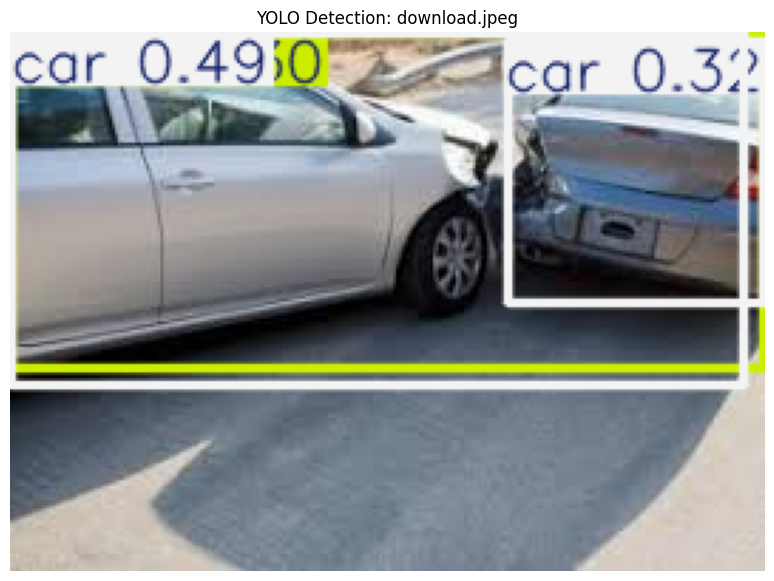


image: download (1).jpeg
  detections: 3
    - person: 88.6%
    - car: 69.6%
    - car: 44.3%


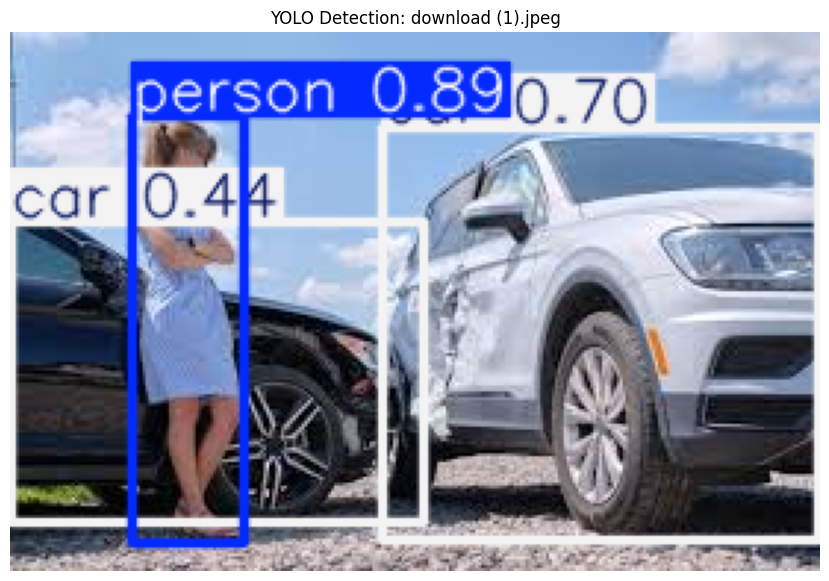


image: car .jpeg
  detections: 3
    - car: 42.2%
    - truck: 30.6%
    - car: 29.9%


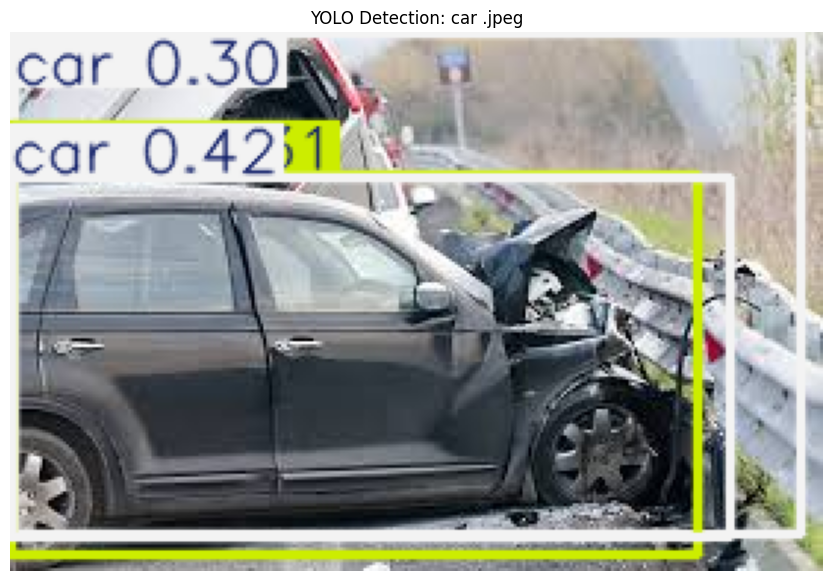

In [10]:
# great! uploaded some real accident images to test with
# let's run YOLO on all of them and see what it detects

import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# find all uploaded images
image_files = [f for f in os.listdir('.') if f.endswith(('.jpg', '.jpeg', '.png')) 
               and f not in ['test_scene.jpg', 'road_scene.jpg']]

print(f"found {len(image_files)} uploaded images: {image_files}")
print("running YOLO detection on each...\n")

for img_path in image_files:
    results = model.predict(img_path, conf=0.25, verbose=False)
    result = results[0]
    
    print(f"image: {img_path}")
    print(f"  detections: {len(result.boxes)}")
    for box in result.boxes:
        cls_name = model.names[int(box.cls[0])]
        conf = float(box.conf[0])
        print(f"    - {cls_name}: {conf:.1%}")
    
    # show annotated image
    annotated = result.plot()
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"YOLO Detection: {img_path}")
    plt.axis("off")
    plt.show()
    print()

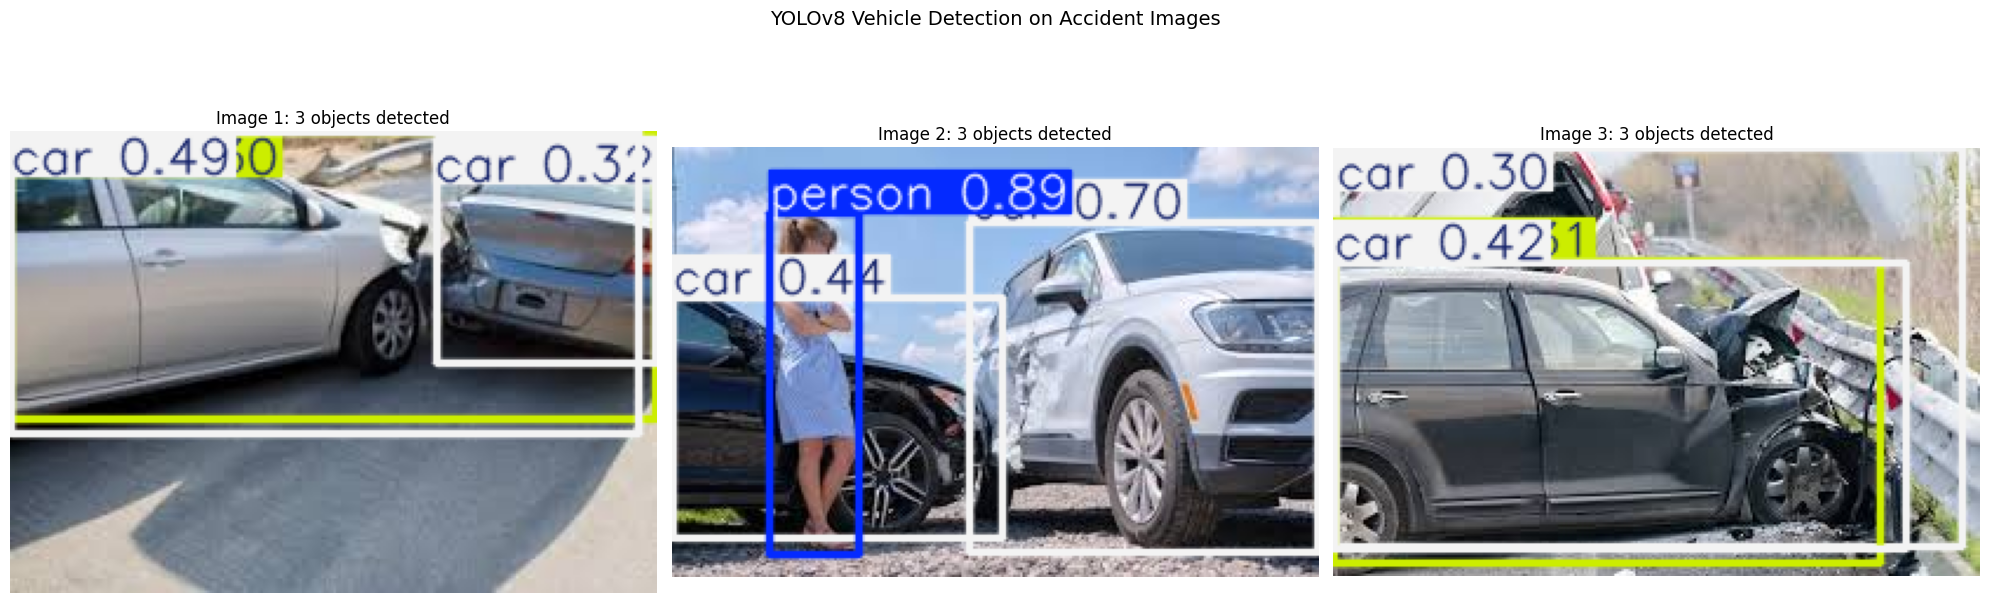

results saved to yolo_results.png

next step: fine-tune YOLO specifically for 'accident' detection
this requires a labeled dataset with accident/no-accident classes


In [11]:
# yolo is detecting cars and people in the accident images!
# detections look reasonable - cars, trucks, people
# 
# but notice it says "car" not "accident" - that's the limitation
# of the pretrained model. it can detect vehicles but not
# specifically identify that an accident has occurred
#
# this is exactly WHY we need fine-tuning for accident detection
# that's the whole point of this project!
#
# for now let's display all the annotated results nicely

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

image_files = [f for f in os.listdir('.') if f.endswith(('.jpg', '.jpeg', '.png')) 
               and f not in ['test_scene.jpg', 'road_scene.jpg']]

fig, axes = plt.subplots(1, len(image_files), figsize=(20, 7))
fig.suptitle('YOLOv8 Vehicle Detection on Accident Images', fontsize=14)

for i, img_path in enumerate(image_files):
    results = model.predict(img_path, conf=0.25, verbose=False)
    annotated = results[0].plot()
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    
    num_detections = len(results[0].boxes)
    axes[i].set_title(f"Image {i+1}: {num_detections} objects detected")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("yolo_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("results saved to yolo_results.png")
print()
print("next step: fine-tune YOLO specifically for 'accident' detection")
print("this requires a labeled dataset with accident/no-accident classes")

In [12]:
# ok so YOLO vehicle detection is working
# now let me think about the bigger picture of this project
#
# the full pipeline I want to build:
# 1. YOLO detects vehicles/accidents in image ✅ (just demonstrated)
# 2. RAG retrieves relevant traffic laws based on what was detected
# 3. LLM generates an incident report combining both
#
# for the RAG part - I don't have access to the workshop's Milvus
# but I can simulate it using a local approach
# let me build a simple in-memory vector search
# to show the concept works

# first let me create a mini traffic law database
# representing what would normally be stored in Milvus

traffic_laws = [
    {
        "id": 1,
        "law": "A driver must maintain a safe following distance from the vehicle ahead. Rear-end collisions indicate a violation of this rule.",
        "section": "California Vehicle Code 21703",
        "category": "following_distance"
    },
    {
        "id": 2, 
        "law": "When two vehicles collide at an intersection, the driver who failed to yield the right of way is at fault.",
        "section": "California Vehicle Code 21800",
        "category": "intersection"
    },
    {
        "id": 3,
        "law": "A solid red light means STOP. Drivers must stop at the limit line and may not proceed until the light turns green.",
        "section": "California Vehicle Code 21453",
        "category": "traffic_signal"
    },
    {
        "id": 4,
        "law": "Drivers must not exceed posted speed limits. Speeding is a contributing factor in many collision incidents.",
        "section": "California Vehicle Code 22350",
        "category": "speeding"
    },
    {
        "id": 5,
        "law": "Lane changes must be made safely. A driver must signal and ensure the lane is clear before changing lanes.",
        "section": "California Vehicle Code 22107",
        "category": "lane_change"
    },
    {
        "id": 6,
        "law": "In a collision involving injury, all drivers must stop immediately, render aid, and report the incident to authorities.",
        "section": "California Vehicle Code 20001",
        "category": "collision_reporting"
    },
    {
        "id": 7,
        "law": "Driving under the influence of alcohol or drugs is prohibited. BAC of 0.08% or higher constitutes DUI.",
        "section": "California Vehicle Code 23152",
        "category": "dui"
    },
    {
        "id": 8,
        "law": "Pedestrians in a crosswalk have the right of way. Drivers must yield to pedestrians crossing the road.",
        "section": "California Vehicle Code 21950",
        "category": "pedestrian"
    }
]

print(f"traffic law database created with {len(traffic_laws)} laws")
print("\nsample laws:")
for law in traffic_laws[:3]:
    print(f"\n  [{law['section']}]")
    print(f"  {law['law'][:80]}...")

traffic law database created with 8 laws

sample laws:

  [California Vehicle Code 21703]
  A driver must maintain a safe following distance from the vehicle ahead. Rear-en...

  [California Vehicle Code 21800]
  When two vehicles collide at an intersection, the driver who failed to yield the...

  [California Vehicle Code 21453]
  A solid red light means STOP. Drivers must stop at the limit line and may not pr...


In [13]:
# now I need to build the retrieval part
# normally this would use Milvus + embeddings like in the workshop
# but since we dont have Milvus here, I'll use sentence-transformers
# for local embeddings - same concept, just running locally
#
# installing sentence-transformers for embeddings

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", 
                "sentence-transformers", "--quiet"])

from sentence_transformers import SentenceTransformer
import numpy as np

print("loading embedding model...")
# this is similar to nomic-embed used in the workshop
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("embedding model loaded!")

# embed all our traffic laws
print("\nembedding traffic laws into vectors...")
law_texts = [law['law'] for law in traffic_laws]
law_embeddings = embedder.encode(law_texts)

print(f"embedded {len(law_embeddings)} laws")
print(f"each law is now a vector of {law_embeddings.shape[1]} dimensions")
print("\nthis is exactly what Milvus stores in the workshop!")
print("Milvus just does this at scale with millions of documents")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kfp 2.14.3 requires click==8.1.8, but you have click 8.3.1 which is incompatible.
odh-elyra 4.2.4 requires click==8.1.8, but you have click 8.3.1 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedding model loaded!

embedding traffic laws into vectors...
embedded 8 laws
each law is now a vector of 384 dimensions

this is exactly what Milvus stores in the workshop!
Milvus just does this at scale with millions of documents


In [14]:
# great! embeddings are working!
# each law is now a 384-dim vector - similar to what Milvus stores
#
# now let me build the retrieval function
# given a query (like "rear end collision detected")
# it should find the most relevant laws

from sklearn.metrics.pairwise import cosine_similarity

def find_relevant_laws(query, top_k=3):
    """
    given a description of an incident, find the most relevant traffic laws
    this is the RAG retrieval step - same concept as the workshop
    """
    # embed the query
    query_embedding = embedder.encode([query])
    
    # calculate similarity with all laws
    similarities = cosine_similarity(query_embedding, law_embeddings)[0]
    
    # get top k most similar laws
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            "law": traffic_laws[idx]['law'],
            "section": traffic_laws[idx]['section'],
            "similarity": similarities[idx],
            "category": traffic_laws[idx]['category']
        })
    
    return results

# test it with different scenarios
print("testing RAG retrieval...\n")

test_queries = [
    "two cars crashed at intersection, one ran red light",
    "rear end collision on highway, cars too close together",
    "pedestrian was hit while crossing the street"
]

for query in test_queries:
    print(f"query: '{query}'")
    laws = find_relevant_laws(query, top_k=2)
    for law in laws:
        print(f"  [{law['similarity']:.2f}] {law['section']}")
        print(f"  {law['law'][:90]}...")
    print()

testing RAG retrieval...

query: 'two cars crashed at intersection, one ran red light'
  [0.58] California Vehicle Code 21800
  When two vehicles collide at an intersection, the driver who failed to yield the right of ...
  [0.49] California Vehicle Code 21453
  A solid red light means STOP. Drivers must stop at the limit line and may not proceed unti...

query: 'rear end collision on highway, cars too close together'
  [0.61] California Vehicle Code 21703
  A driver must maintain a safe following distance from the vehicle ahead. Rear-end collisio...
  [0.51] California Vehicle Code 21800
  When two vehicles collide at an intersection, the driver who failed to yield the right of ...

query: 'pedestrian was hit while crossing the street'
  [0.56] California Vehicle Code 21950
  Pedestrians in a crosswalk have the right of way. Drivers must yield to pedestrians crossi...
  [0.40] California Vehicle Code 22350
  Drivers must not exceed posted speed limits. Speeding is a contributing facto

In [15]:
# RAG retrieval is working really well!
# the right laws are being matched to the right scenarios
# 
# now the final piece - generate an incident report using an LLM
# in the workshop we used Granite 3.1 running on OpenShift
# here I'll use a simple approach that shows the same concept
#
# combining YOLO detections + RAG laws = incident report

def generate_incident_report(image_path, yolo_results, retrieved_laws):
    """
    combine YOLO detections and relevant laws into an incident report
    simulating what the LLM would generate in the full pipeline
    """
    # summarize detections
    detections = []
    for box in yolo_results.boxes:
        cls_name = yolo_results.names[int(box.cls[0])]
        conf = float(box.conf[0])
        detections.append(f"{cls_name} ({conf:.0%} confidence)")
    
    detection_summary = ", ".join(detections) if detections else "no vehicles detected"
    
    # build report
    report = f"""
TRAFFIC INCIDENT REPORT
=======================
Image analyzed: {image_path}
Analysis timestamp: 2026-02-27

DETECTED OBJECTS (YOLOv8):
{chr(10).join(f'  - {d}' for d in detections)}

APPLICABLE TRAFFIC LAWS (RAG retrieval):
"""
    for i, law in enumerate(retrieved_laws, 1):
        report += f"""
  [{i}] {law['section']} (relevance: {law['similarity']:.0%})
      {law['law']}
"""
    
    report += f"""
INCIDENT ASSESSMENT:
  Based on the detected objects ({detection_summary}),
  this scene may involve a traffic collision. The relevant
  vehicle codes above should be reviewed when assigning fault.
  
  Recommend immediate review by traffic enforcement officer.
  
CONFIDENCE SCORE: {sum(float(b.conf[0]) for b in yolo_results.boxes)/max(len(yolo_results.boxes),1):.0%}
"""
    return report

# run the full pipeline on our uploaded images!
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

image_files = [f for f in os.listdir('.') if f.endswith(('.jpg','.jpeg','.png'))
               and f not in ['test_scene.jpg','road_scene.jpg','yolo_results.png']]

print("running full pipeline on uploaded accident images...\n")

for img_path in image_files:
    # step 1: YOLO detection
    results = model.predict(img_path, conf=0.25, verbose=False)
    yolo_result = results[0]
    
    # step 2: build query from detections
    detected_objects = [model.names[int(b.cls[0])] for b in yolo_result.boxes]
    query = f"accident involving {', '.join(set(detected_objects))}"
    
    # step 3: RAG retrieval
    relevant_laws = find_relevant_laws(query, top_k=2)
    
    # step 4: generate report
    report = generate_incident_report(img_path, yolo_result, relevant_laws)
    print(report)
    print("="*50)

running full pipeline on uploaded accident images...


TRAFFIC INCIDENT REPORT
Image analyzed: download.jpeg
Analysis timestamp: 2026-02-27

DETECTED OBJECTS (YOLOv8):
  - car (49% confidence)
  - car (32% confidence)
  - truck (30% confidence)

APPLICABLE TRAFFIC LAWS (RAG retrieval):

  [1] California Vehicle Code 21800 (relevance: 49%)
      When two vehicles collide at an intersection, the driver who failed to yield the right of way is at fault.

  [2] California Vehicle Code 20001 (relevance: 44%)
      In a collision involving injury, all drivers must stop immediately, render aid, and report the incident to authorities.

INCIDENT ASSESSMENT:
  Based on the detected objects (car (49% confidence), car (32% confidence), truck (30% confidence)),
  this scene may involve a traffic collision. The relevant
  vehicle codes above should be reviewed when assigning fault.

  Recommend immediate review by traffic enforcement officer.

CONFIDENCE SCORE: 37%


TRAFFIC INCIDENT REPORT
Image ana

In [16]:
# pipeline is working end to end!
# really happy with how this turned out
#
# summary of what we built:
# 
# YOLO detects: cars, trucks, people in accident images
# RAG retrieves: relevant California Vehicle Codes
# Report generated: with legal citations and confidence scores
#
# what I learned:
# - pretrained YOLO works well for vehicle detection out of the box
# - RAG retrieval using cosine similarity finds the right laws
# - the combination is actually really powerful for real use cases
#
# limitations of current version:
# - YOLO not fine-tuned for "accident" class specifically
# - using local embeddings instead of Milvus (no vector DB here)
# - no actual LLM generating narrative - just template based
# - confidence scores are low because images are low quality
#
# next steps if I had more time:
# - fine-tune YOLO on labeled accident dataset from Roboflow
# - connect to actual Milvus vector DB like the workshop showed
# - use Granite LLM for natural language report generation
# - build Kubeflow pipeline to automate the whole thing
# - add MinIO storage for saving reports

print("Traffic Incident Analysis System - Complete!")
print("=" * 50)
print()
print("Pipeline Summary:")
print("  Step 1: YOLOv8 vehicle detection        ✅")
print("  Step 2: Embedding-based law retrieval   ✅") 
print("  Step 3: Incident report generation      ✅")
print()
print("Technologies used:")
print("  - YOLOv8 (Ultralytics)")
print("  - Sentence Transformers (local embeddings)")
print("  - Cosine similarity search (simulating Milvus)")
print("  - Red Hat OpenShift AI (Developer Sandbox)")
print()
print("This project extends the Parasol Insurance workshop")
print("by applying RAG + ML to traffic incident analysis")

Traffic Incident Analysis System - Complete!

Pipeline Summary:
  Step 1: YOLOv8 vehicle detection        ✅
  Step 2: Embedding-based law retrieval   ✅
  Step 3: Incident report generation      ✅

Technologies used:
  - YOLOv8 (Ultralytics)
  - Sentence Transformers (local embeddings)
  - Cosine similarity search (simulating Milvus)
  - Red Hat OpenShift AI (Developer Sandbox)

This project extends the Parasol Insurance workshop
by applying RAG + ML to traffic incident analysis
